In [1]:




from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import requests
file_url = "https://storage.googleapis.com/ads-dataset/subfolder-10.zip"

r = requests.get(file_url, stream = True)

with open("/content/gdrive/My Drive/subfolder-10.zip", "wb") as file:
	for block in r.iter_content(chunk_size = 1024):
		if block:
			file.write(block)


In [3]:
!unzip "/content/gdrive/My Drive/subfolder-10.zip"

Streaming output truncated to the last 5000 lines.
  inflating: 10/173349.png           
  inflating: 10/173350.png           
  inflating: 10/173351.png           
  inflating: 10/173352.png           
  inflating: 10/173353.png           
  inflating: 10/173354.png           
  inflating: 10/173355.png           
  inflating: 10/173356.png           
  inflating: 10/173357.png           
  inflating: 10/173358.png           
  inflating: 10/173359.png           
  inflating: 10/173360.png           
  inflating: 10/173361.png           
  inflating: 10/173362.png           
  inflating: 10/173363.png           
  inflating: 10/173364.png           
  inflating: 10/173365.png           
  inflating: 10/173366.png           
  inflating: 10/173367.png           
  inflating: 10/173368.png           
  inflating: 10/173369.png           
  inflating: 10/173370.png           
  inflating: 10/173371.png           
  inflating: 10/173372.png           
  inflating: 10/173373.png           

In [4]:
import torch.nn as nn

# Generator Model
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # State size: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output size: (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input size: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # Output size: 1
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

In [12]:
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader

# Hyperparameters
batch_size = 128
image_size = 64
nz = 100  # Size of z latent vector
ngf = 64  # Size of feature maps in generator
ndf = 64  # Size of feature maps in discriminator
num_epochs = 25
lr = 0.0002
beta1 = 0.5
nc = 3  # Number of color channels

# Data Transformation
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*nc, [0.5]*nc)
])

# Load Dataset
# Replace 'path_to_images' with the path to your image dataset
dataset = datasets.ImageFolder(root="/content/data", transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
dataloader.dataset

Dataset ImageFolder
    Number of datapoints: 8348
    Root location: /content/data
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [13]:
import torch.optim as optim

# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize Generator and Discriminator
netG = Generator(nz, ngf, nc).to(device)
netD = Discriminator(nc, ndf).to(device)

# Initialize weights
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

# Loss Function
criterion = nn.BCELoss()

# Create labels
real_label = 1.
fake_label = 0.

# Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

Using device: cuda


In [2]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from tqdm.notebook import tqdm

# Lists to keep track of progress
G_losses = []
D_losses = []
img_list = []
iters = 0

print("Starting DCGAN Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        ############################
        # (1) Update D network
        ###########################
        netD.zero_grad()
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_images)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)
        output = netD(fake_images.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # Generator wants discriminator to believe fake images are real
        output = netD(fake_images)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check progress
        if i % 100 == 0:
            print(f'[{epoch+1}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

        iters += 1

    # Save fake images for visualization
    with torch.no_grad():
        fake = netG(torch.randn(64, nz, 1, 1, device=device)).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

    # Optionally, save images after each epoch
    vutils.save_image(fake, f"/content/dcgan_images/fake_epoch_{epoch+1}.png", normalize=True)

Starting DCGAN Training Loop...


NameError: name 'num_epochs' is not defined

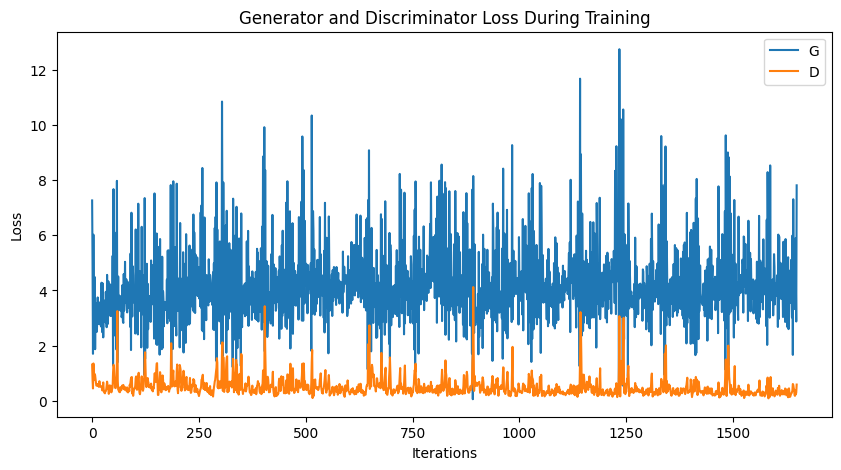

In [ ]:
import numpy as np
# Plotting the losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualize Generated Images
import matplotlib.pyplot as plt

# Animation of generated images over epochs (requires additional setup)
from IPython.display import HTML
import matplotlib.animation as animation

fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i, (1,2,0))), plt.title("Epoch")] for i in img_list]

ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

In [ ]:
# prompt: WRITE CODE TO save the above trained model

import torch

# Assuming 'netG' and 'netD' are your trained generator and discriminator models
# Save the generator model
torch.save(netG.state_dict(), '/content/gdrive/My Drive/generator_model.pth')

# Save the discriminator model (optional, but recommended)
torch.save(netD.state_dict(), '/content/gdrive/My Drive/discriminator_model.pth')

print("Models saved to Google Drive.")